**Import necessary libraries**

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

**Load Dataset**

In [7]:
df = pd.read_csv("/content/synthetic_patient_dataset (1).csv")

df.head()

,symptoms,symptom_count,severity_score,red_flag_count,triage,disease
0,confusion;fever,2,7,1,moderate,Meningitis
1,vomiting;upper abdominal pain;skin peeling;fever,4,9,0,moderate,Pancreatitis
2,nausea;abdominal pain;vomiting;breast swelling,4,10,0,urgent,Gastritis
3,hand pain;swollen lymph nodes;leg cramps;hand ...,4,5,0,low,Carpal Tunnel Syndrome
4,joint swelling;joint pain;difficulty opening m...,3,7,0,moderate,Gout


**Basic Dataset Info**

In [8]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (50000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   symptoms        50000 non-null  object
 1   symptom_count   50000 non-null  int64 
 2   severity_score  50000 non-null  int64 
 3   red_flag_count  50000 non-null  int64 
 4   triage          50000 non-null  object
 5   disease         50000 non-null  object
dtypes: int64(3), object(3)
memory usage: 2.3+ MB


**Check missing values**

In [9]:
df.isnull().sum()

,0
symptoms,0
symptom_count,0
severity_score,0
red_flag_count,0
triage,0
disease,0


**Triage Distribution Visualization**

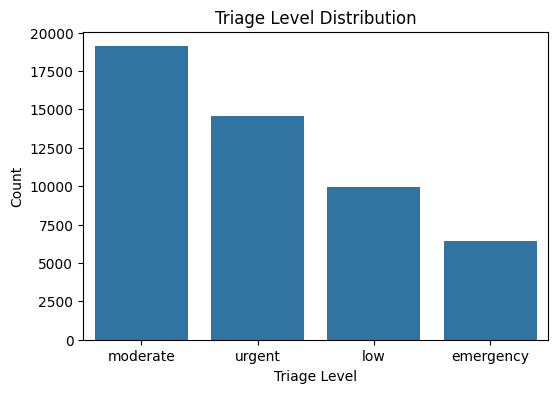

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x="triage", data=df)

plt.title("Triage Level Distribution")
plt.xlabel("Triage Level")
plt.ylabel("Count")

plt.show()

**Severity score Distribution**

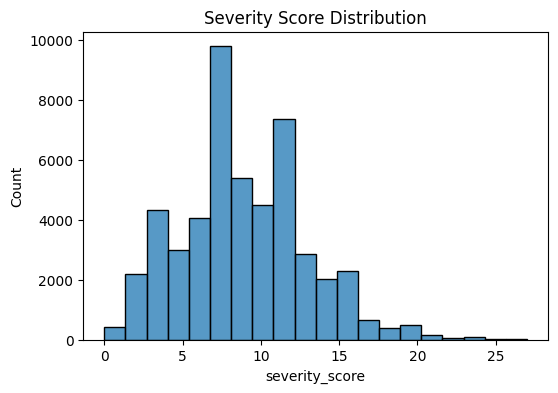

In [11]:
plt.figure(figsize=(6,4))

sns.histplot(df["severity_score"], bins=20)

plt.title("Severity Score Distribution")

plt.show()

**Symptom count Distribution**

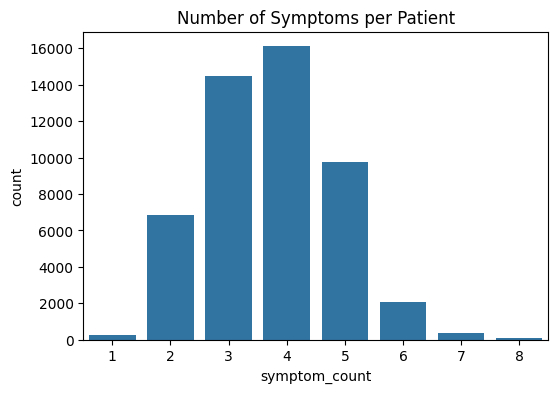

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x="symptom_count", data=df)

plt.title("Number of Symptoms per Patient")

plt.show()

**Convert symptoms to List**

In [13]:
df["symptom_list"] = df["symptoms"].apply(lambda x: x.split(";"))

df.head()

,symptoms,symptom_count,severity_score,red_flag_count,triage,disease,symptom_list
0,confusion;fever,2,7,1,moderate,Meningitis,"[confusion, fever]"
1,vomiting;upper abdominal pain;skin peeling;fever,4,9,0,moderate,Pancreatitis,"[vomiting, upper abdominal pain, skin peeling,..."
2,nausea;abdominal pain;vomiting;breast swelling,4,10,0,urgent,Gastritis,"[nausea, abdominal pain, vomiting, breast swel..."
3,hand pain;swollen lymph nodes;leg cramps;hand ...,4,5,0,low,Carpal Tunnel Syndrome,"[hand pain, swollen lymph nodes, leg cramps, h..."
4,joint swelling;joint pain;difficulty opening m...,3,7,0,moderate,Gout,"[joint swelling, joint pain, difficulty openin..."


**Convert symptoms to Binary Features**

In [14]:
mlb = MultiLabelBinarizer()

symptom_matrix = mlb.fit_transform(df["symptom_list"])

symptom_df = pd.DataFrame(symptom_matrix, columns=mlb.classes_)

**Combine features**

In [15]:
X = pd.concat([
    symptom_df,
    df[["severity_score"]]
], axis=1)

y=df["triage"]

**Train/Test split**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Train Random Forest**

In [17]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

**Predictions**

In [18]:
pred = model.predict(X_test)

**Accuracy**

In [19]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9133


**Classification report**

In [20]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

   emergency       1.00      0.62      0.77      1318
         low       0.99      0.82      0.90      1971
    moderate       0.91      1.00      0.95      3742
      urgent       0.86      1.00      0.93      2969

    accuracy                           0.91     10000
   macro avg       0.94      0.86      0.89     10000
weighted avg       0.92      0.91      0.91     10000



**Confusion Matrix**

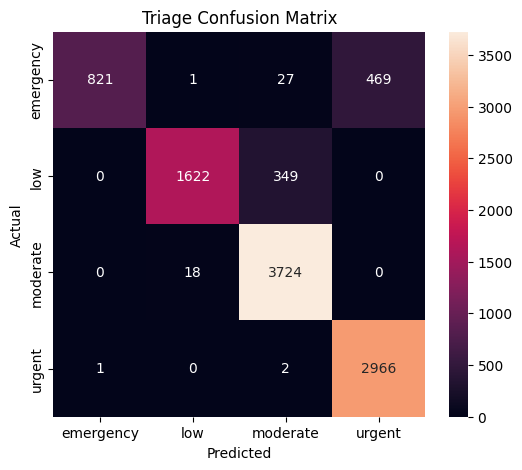

In [21]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Triage Confusion Matrix")

plt.show()

**Saving the Model**

In [38]:
import joblib
joblib.dump(model, "triage_model.pkl")

['triage_model.pkl']

**Saving the symptom Encoder**

In [39]:
joblib.dump(mlb,"symptom_encoder.pkl")

['symptom_encoder.pkl']

**Saving Feature column order**

In [40]:
joblib.dump(X.columns.tolist(), "triage_features.pkl")

['triage_features.pkl']

**Prediction Cases**

In [28]:
def predict_triage_probability(symptoms, severity_score):
    if isinstance(symptoms, str):
        symptoms = symptoms.split(";")
    symptom_vector = mlb.transform([symptoms])
    symptom_df_test = pd.DataFrame(symptom_vector, columns=mlb.classes_)
    symptom_df_test["severity_score"] = severity_score
    pred = model.predict(symptom_df_test)[0]
    probs = model.predict_proba(symptom_df_test)[0]
    prob_dict = {k: float(v) for k,v in zip(model.classes_, probs)}
    return pred, prob_dict

**Prediction Test case - 1**

In [29]:
symptoms = "cough;runny nose;fatigue"
severity_score = 4

result = predict_triage_probability(symptoms, severity_score)

print("Symptoms:", symptoms)
print("Predicted Triage:", result)

Symptoms: cough;runny nose;fatigue
Predicted Triage: ('moderate', {'emergency': 0.05501037651475891, 'low': 0.32359176718013344, 'moderate': 0.4482064475807577, 'urgent': 0.17319140872434965})


**Prediction Test case - 2**

In [30]:
symptoms = "fever;cough;fatigue;headache"
severity_score = 7

result = predict_triage_probability(symptoms, severity_score)

print("Symptoms:", symptoms)
print("Predicted Triage:", result)

Symptoms: fever;cough;fatigue;headache
Predicted Triage: ('moderate', {'emergency': 0.106290240130146, 'low': 0.0996083337615741, 'moderate': 0.5505681636120124, 'urgent': 0.24353326249626753})


**Prediction Test case - 3**

In [31]:
symptoms = "chest pain;shortness of breath;fatigue"
severity_score = 11

result = predict_triage_probability(symptoms, severity_score)

print("Symptoms:", symptoms)
print("Predicted Triage:", result)

Symptoms: chest pain;shortness of breath;fatigue
Predicted Triage: ('emergency', {'emergency': 0.5415616784219892, 'low': 0.0194181720878681, 'moderate': 0.11039042954719455, 'urgent': 0.32862971994294826})


**Prediction Test case - 4**

In [32]:
symptoms = "chest pain;loss of consciousness;shortness of breath"
severity_score = 18

result = predict_triage_probability(symptoms, severity_score)

print("Symptoms:", symptoms)
print("Predicted Triage:", result)

Symptoms: chest pain;loss of consciousness;shortness of breath
Predicted Triage: ('emergency', {'emergency': 0.6271133564141743, 'low': 0.031761785196466316, 'moderate': 0.12140259251447856, 'urgent': 0.21972226587488083})


In [35]:
symptoms = "chest pain;shortness of breath"

predict_triage_probability(symptoms, 12)

('emergency',
 {'emergency': 0.4963053566343501,
  'low': 0.03884516898459347,
  'moderate': 0.145401453718785,
  'urgent': 0.31944802066227146})